## Hausa Sentiment Analysis
### Compares Logistic Regression (TF-IDF), DidtilBert and mBERT for sentiment classification

@dataset{hausa_sentiments_corpus,
  title={Hausa Sentiment Corpus},
  author={Mich-Seth Owusu},
  year={2025},
  url={https://huggingface.co/datasets/michsethowusu/hausa-sentiments-corpus}
}

#### 1. Load Dataset 'mangaphd/hausaBERTdatatrain' from Hugging Face

In [1]:
#Import required modules
from pathlib import Path
import pandas as pd
import numpy as np
from datasets import load_dataset
import pickle
import warnings
warnings.filterwarnings('ignore')

#Set base path
PATH = Path(_dh[0]).resolve()

print("Loading HausaSent dataset...")
try:
    # Try to load from Hugging Face
    dataset = load_dataset("mangaphd/hausaBERTdatatrain") 
    dataset.head()

    #Flag that data is loaded from HF 
    data_source = 'HF'

    # Alternative: load from local parquet file if HF doesn't work
except:  
    # Set File Path
    FilePath = PATH / r"train-00000-of-00001-e98ce2b8b4313d56.parquet"
    print(f"HF dataset not found. Attempting to load dataset from: {FilePath}")
    
    # Read data
    dataset = pd.read_parquet(FilePath)
    print(dataset.head(), f'Data size: {dataset.shape[0]}')

    #Flag that data is loaded from local drive 
    data_source = 'local drive'

c:\Users\User\Desktop\Mr Ope\GrandMEAN_Portfolio\Research\NLP\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading HausaSent dataset...


HF dataset not found. Attempting to load dataset from: C:\Users\User\Desktop\Mr Ope\GrandMEAN_Portfolio\Research\NLP\HausaSentiment\train-00000-of-00001-e98ce2b8b4313d56.parquet
                                               Hausa sentiment  \
0  Kuma lalle ne gidan Lahira shi ne mafi alheri ...  Negative   
1          Gaskantawa da Yesu ma bangare ne na tuba.  Negative   
2       Tafkin wutan nan kuwa shi ne mutuwa ta biyu.  Negative   
3                  A sunana, Za su fitar da aljannu.  Positive   
4  Yahi Dhoka Duniya Chalati Hai Yahi Sara Game Hai,  Positive   

   __index_level_0__  
0                  0  
1                  1  
2                  2  
3                  3  
4                  4   Data size: 669937


In [ ]:
#2. Basic EDA and cleaning
#================================================================================

#import regex library
import re

#Check dataset for nulls and duplicates
dataset.info()
print(dataset.isna().sum())
print(dataset['Hausa'].unique().shape)

#Check dataset for email addresses
for index, row in dataset.iterrows():
    emails = re.findall(r'\b[\w.-]+@[\w.-]+\.\w+\b', row['Hausa'])

print("Emails Found:", emails)


<class 'pandas.DataFrame'>
RangeIndex: 669937 entries, 0 to 669936
Data columns (total 3 columns):
 #   Column             Non-Null Count   Dtype
---  ------             --------------   -----
 0   Hausa              669937 non-null  str  
 1   sentiment          669937 non-null  str  
 2   __index_level_0__  669937 non-null  int64
dtypes: int64(1), str(2)
memory usage: 61.0 MB
Hausa                0
sentiment            0
__index_level_0__    0
dtype: int64
(669937,)


'\nfor index, row in dataset.iterrows():\n    emails = re.findall(r\'\x08[\\w.-]+@[\\w.-]+\\.\\w+\x08\', row[\'Hausa\'])\n\nprint("Emails Found:", emails)\n'

#### 2. Take a random sample of 400 records to work with for this demo

In [2]:

dataset_sample = dataset.sample(n=400, random_state=42)

#Split dataset into texts and labels
texts = dataset_sample['Hausa']
labels = dataset_sample['sentiment']

# Convert to lists if needed
if not isinstance(texts, list):
    texts = list(texts)
if not isinstance(labels, list):
    labels = list(labels)

# Display dataset info
print(f"\nDataset Statistics:")
print(f"  Total samples: {len(texts)}")

unique, counts = np.unique(labels, return_counts=True)
print(f"  Positive (1): {counts[1] if len(counts) > 1 else 0} samples")
print(f"  Negative (0): {counts[0] if len(counts) > 0 else 0} samples")


Dataset Statistics:
  Total samples: 400
  Positive (1): 210 samples
  Negative (0): 190 samples


#### 3. Split dataset into training and test sets

In [3]:
#Import train_test_split
from sklearn.model_selection import train_test_split

#Spllit dataset into training and test sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    texts, labels, test_size=0.3, random_state=42, stratify=labels
)
print(f"Training samples: {len(X_train)}, Test samples: {len(X_test)}")

Training samples: 280, Test samples: 120


#### 4. CLASSICAL MODEL: Logistic Regression + TF-IDF

In [4]:
#Import needed modules for classical model
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
import time

# Vectorise text
vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1,2))
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

# Train model
start_time = time.time()
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_tfidf, y_train)
train_time_lr = time.time() - start_time

# Predict and evaluate
y_pred_lr = lr_model.predict(X_test_tfidf)

In [5]:
# Import modules for evaluation
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, classification_report

#Measure Inference latency
latencies = []
for i in range(100):  # measure over 100 samples
    start = time.time()
    _ = lr_model.predict(X_test_tfidf[i:i+1])
    latencies.append(time.time() - start)
avg_latency_lr = np.mean(latencies) * 1000  # convert to ms

# Metrics
acc_lr = accuracy_score(y_test, y_pred_lr)
f1_lr = f1_score(y_test, y_pred_lr, average='weighted')
prec_lr = precision_score(y_test, y_pred_lr, average='weighted')
rec_lr = recall_score(y_test, y_pred_lr, average='weighted')

#Print results
print("\n" + "="*50)
print("CLASSICAL MODEL: Logistic Regression")
print("="*50)

print(f"\n Performance Metrics:")
print(f"  Accuracy:  {acc_lr:.4f}")
print(f"  F1 Score:  {f1_lr:.4f}")
print(f"  Precision: {prec_lr:.4f}")
print(f"  Recall:    {rec_lr:.4f}")
print(f"\n Efficiency:")
print(f"  Training time: {train_time_lr:.2f} seconds")
print(f"  Inference latency: {avg_latency_lr:.2f} ms/sample")

# Classification report
print(f"\n Detailed Classification Report:")
print(classification_report(y_test, y_pred_lr, target_names=['Negative', 'Positive']))

# Save the model
with open(PATH / 'models/LogisticRegression.pkl', 'wb') as f:
    pickle.dump(lr_model, f)


CLASSICAL MODEL: Logistic Regression

 Performance Metrics:
  Accuracy:  0.5583
  F1 Score:  0.5484
  Precision: 0.5563
  Recall:    0.5583

 Efficiency:
  Training time: 0.07 seconds
  Inference latency: 1.29 ms/sample

 Detailed Classification Report:
              precision    recall  f1-score   support

    Negative       0.55      0.40      0.46        57
    Positive       0.56      0.70      0.62        63

    accuracy                           0.56       120
   macro avg       0.56      0.55      0.54       120
weighted avg       0.56      0.56      0.55       120



In [6]:
# Compile results into a DataFrame for comparison
results_dict = {
    'model': 'LogisticRegression',
    'eval_accuracy': acc_lr,
    'eval_f1': f1_lr,
    'eval_precision': prec_lr,
    'eval_recall': rec_lr,
    'training time (s)': train_time_lr,
    'inference latency (ms)': avg_latency_lr
}

df_comparison = pd.DataFrame(results_dict, index=[0])
print(df_comparison.to_string)

<bound method DataFrame.to_string of                 model  eval_accuracy   eval_f1  eval_precision  eval_recall  \
0  LogisticRegression       0.558333  0.548367        0.556273     0.558333   

   training time (s)  inference latency (ms)  
0            0.07164                1.286664  >


#### 4. TRANSFORMER MODEL: mBERT and Distilbert

In [14]:
# Import modules for transformer model
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments, EarlyStoppingCallback
from datasets import Dataset, ClassLabel
import torch
import os, psutil
from cpuinfo import get_cpu_info

# Use first GPU
os.environ["CUDA_VISIBLE_DEVICES"] = "0"  

# Check device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

info = get_cpu_info()
logical_cores = psutil.cpu_count(logical=True)
physical_cores = psutil.cpu_count(logical=False)
print(f"CPU Brand: {info['brand_raw']}")
print(f"Arch: {info['arch']}")
print(f"Max Frequency: {info['hz_advertised_friendly']}")
print(f"Logical Cores: {logical_cores}")
print(f"Physical Cores: {physical_cores}")

#Empty dictionary for model iterations
models_cm = {}
eval_dict = {}
eval_data = {}

Using device: cpu
CPU Brand: AMD A4-6210 APU with AMD Radeon R3 Graphics
Arch: X86_64
Max Frequency: 1.7970 GHz
Logical Cores: 4
Physical Cores: 4


In [17]:
# Load tokenizer and distilbert model
model_name = "distilbert-base-multilingual-cased" 
tokenizer = AutoTokenizer.from_pretrained(model_name)

In [28]:
# Load tokenizer and bert model
model_name = "bert-base-multilingual-cased" #"distilbert-base-multilingual-cased"  2x faster
tokenizer = AutoTokenizer.from_pretrained(model_name)

In [30]:
# Prepare dataset for Trainer

def prepare_huggingface_dataset(texts, labels):
    
    unique_labels = sorted(set(labels))
    label_mapping = {label: i for i, label in enumerate(unique_labels)}
    
    # Map string labels to integers
    labels_int = [label_mapping[label] for label in labels]
    
    data_dict = {
        'text': texts,
        'label': labels_int
    }
    
    # Create dataset
    dataset = Dataset.from_dict(data_dict)
    
    # Convert to ClassLabel
    dataset = dataset.cast_column('label', ClassLabel(names=unique_labels))
    
    return dataset

full_dataset = prepare_huggingface_dataset(texts, labels)


Casting the dataset:   0%|          | 0/400 [00:00<?, ? examples/s]

Casting the dataset: 100%|██████████| 400/400 [00:00<00:00, 18347.79 examples/s]


In [31]:
# Split into train and test
train_test_split = full_dataset.train_test_split(test_size=0.2, seed=42, stratify_by_column='label')

# Create a smaller validation set from test set
eval_fraction = 0.2 
small_eval = train_test_split['test'].train_test_split(test_size=eval_fraction, seed=42)
eval_dataset = small_eval['test']  
final_test_dataset = small_eval['train'] 

eval_data[f'{model_name}'] = eval_dataset
print(eval_data)

print(f"Training samples: {len(train_test_split['train'])}")
print(f"Evaluation samples (per epoch): {len(eval_dataset)}")
print(f"Final test samples: {len(final_test_dataset)}")

{'distilbert-base-multilingual-cased': Dataset({
    features: ['text', 'label'],
    num_rows: 16
}), 'bert-base-multilingual-cased': Dataset({
    features: ['text', 'label'],
    num_rows: 16
})}
Training samples: 320
Evaluation samples (per epoch): 16
Final test samples: 64


In [32]:
#Set max length based on average text length to optimize
MAX_LENGTH = 256 
# Check average text length to optimize
avg_text_length = np.mean([len(text.split()) for text in texts[:100]])
print(f"Average text length: {avg_text_length:.0f} words")
if avg_text_length < 100:
    MAX_LENGTH = 128 

# Tokenise function
def tokenize_function(examples):
    tokenized = tokenizer(
        examples['text'],
        padding='max_length',
        truncation=True,
        max_length=MAX_LENGTH,
        return_tensors=None
    )
    tokenized['labels'] = examples['label']
    return tokenized

Average text length: 13 words


In [33]:
# Tokenize datasets

print("Tokenizing datasets...")
start_tokenize = time.time()
train_dataset = train_test_split['train'].map(tokenize_function, batched=True, remove_columns=['text'])
eval_dataset = eval_dataset.map(tokenize_function, batched=True, remove_columns=['text'])
final_test_dataset = final_test_dataset.map(tokenize_function, batched=True, remove_columns=['text'])
print(f"Tokenization completed in {time.time() - start_tokenize:.2f}s")

# Set PyTorch format
train_dataset.set_format(type='torch', columns=['input_ids', 'attention_mask', 'labels'])
eval_dataset.set_format(type='torch', columns=['input_ids', 'attention_mask', 'labels'])
final_test_dataset.set_format(type='torch', columns=['input_ids', 'attention_mask', 'labels'])

Tokenizing datasets...


Map: 100%|██████████| 64/64 [00:00<00:00, 1000.22 examples/s]

Tokenization completed in 11.05s


In [34]:
# Load model
num_labels = len(set(labels))
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=num_labels, ignore_mismatched_sizes=True)

model.to(device)

# Training arguments (small for demonstration)
training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=3,
    per_device_train_batch_size=16, 
    per_device_eval_batch_size=32,  
    gradient_accumulation_steps=2, 
    warmup_steps=100,
    weight_decay=0.01,
    logging_dir='./logs',
    logging_steps=50,  
    eval_strategy="steps", 
    eval_steps=500,  # Evaluate every 500 steps
    save_strategy="steps",
    save_steps=500,
    report_to="none",
    save_total_limit=1,
    load_best_model_at_end=True,
    metric_for_best_model="eval_f1",
    learning_rate=2e-5,
    fp16=torch.cuda.is_available(),
    remove_unused_columns=True, 
    dataloader_num_workers=4,  # Parallel data loading
    disable_tqdm=False, 
)

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 261.81it/s]
BertForSequenceClassification LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. C

In [35]:
# Define compute metrics function
def compute_metrics(eval_pred):
    """
    Compute metrics for evaluation
    """
    predictions, labels = eval_pred
    predictions = np.argmax(predictions, axis=1)
    accuracy = accuracy_score(labels, predictions)
    f1 = f1_score(labels, predictions, average='weighted')
    precision = precision_score(labels, predictions, average='weighted')
    recall = recall_score(labels, predictions, average='weighted')
    return {
        'model': model_name,
        'accuracy': accuracy,
        'f1': f1,
        'precision': precision,
        'recall': recall
    }

In [36]:
# Initialize Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,  # Using smaller eval dataset
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
)

# Train and evaluate only once at the end
print("\nStarting training...")
start_time = time.time()
trainer.train()
train_time_bert = time.time() - start_time

# Single final evaluation on full test set
print("\nFinal evaluation on test set...")
eval_results = trainer.predict(final_test_dataset)  # Use predict instead of evaluate
bert_preds = np.argmax(eval_results.predictions, axis=1)



Starting training...


Step,Training Loss,Validation Loss,Model,Accuracy,F1,Precision,Recall
30,No log,0.659519,bert-base-multilingual-cased,0.750000,0.729167,0.737179,0.750000


Writing model shards: 100%|██████████| 1/1 [00:06<00:00,  6.10s/it]
There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer


Final evaluation on test set...


In [37]:
# Calculate metrics from predictions
final_accuracy = accuracy_score(final_test_dataset['labels'], bert_preds)
final_f1 = f1_score(final_test_dataset['labels'], bert_preds, average='weighted')
final_precision = precision_score(final_test_dataset['labels'], bert_preds, average='weighted')
final_recall = recall_score(final_test_dataset['labels'], bert_preds, average='weighted')

print(f"\nFinal Performance Metrics:")
print(f"  Accuracy:  {final_accuracy:.4f}")
print(f"  F1 Score:  {final_f1:.4f}")
print(f"  Precision: {final_precision:.4f}")
print(f"  Recall:    {final_recall:.4f}")
print(f"\nEfficiency:")
print(f"  Training time: {train_time_bert:.2f} seconds")


Final Performance Metrics:
  Accuracy:  0.5781
  F1 Score:  0.5716
  Precision: 0.5887
  Recall:    0.5781

Efficiency:
  Training time: 5041.04 seconds


In [38]:
# Measure inference latency for BERT
model.eval()
latencies_bert = []
with torch.no_grad():
    # Sample 100 random test samples
    test_indices = np.random.choice(len(final_test_dataset), min(100, len(final_test_dataset)), replace=False)
    for idx in test_indices:
        sample = final_test_dataset[idx]
        input_ids = sample['input_ids'].unsqueeze(0).to(device)
        attention_mask = sample['attention_mask'].unsqueeze(0).to(device)
        
        start = time.time()
        _ = model(input_ids=input_ids, attention_mask=attention_mask)
        latencies_bert.append(time.time() - start)

avg_latency_bert = np.mean(latencies_bert) * 1000
print(f"  Inference latency: {avg_latency_bert:.2f} ms/sample")

# Store results in a format compatible for comparison
eval_results_dict = {
    'model': model_name,
    'eval_accuracy': final_accuracy,
    'eval_f1': final_f1,
    'eval_precision': final_precision,
    'eval_recall': final_recall,
    'training time (s)': train_time_bert,
    'inference latency (ms)': avg_latency_bert
}

# Get predictions for confusion matrix
print("\nGenerating predictions for confusion matrix...")
predictions = trainer.predict(eval_dataset)
bert_preds = np.argmax(predictions.predictions, axis=1)

eval_dict[f'model_name'] = eval_results_dict

# Save the model
with open(PATH / f'models/{model_name}.pkl', 'wb') as f:
    pickle.dump(model, f)


  Inference latency: 1892.36 ms/sample

Generating predictions for confusion matrix...


In [39]:
# Add results into a DataFrame for comparison
df_bert_data = pd.DataFrame(eval_dict[f'model_name'], index=[0])
df_comparison = pd.concat([df_comparison, df_bert_data], ignore_index=True)
models_cm[f'{model_name}'] = bert_preds  # Store predictions for confusion matrix analysis

print(df_comparison.to_string)
print(models_cm)

<bound method DataFrame.to_string of                                 model  eval_accuracy   eval_f1  \
0                  LogisticRegression       0.558333  0.548367   
1  distilbert-base-multilingual-cased       0.500000  0.426910   
2        bert-base-multilingual-cased       0.578125  0.571558   

   eval_precision  eval_recall  training time (s)  inference latency (ms)  
0        0.556273     0.558333           0.071640                1.286664  
1        0.524242     0.500000        2379.647193              894.830637  
2        0.588672     0.578125        5041.038840             1892.357860  >
{'distilbert-base-multilingual-cased': array([1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1]), 'bert-base-multilingual-cased': array([1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1])}


#### 5. COMPARISON VISUALISATION

In [40]:
print("\n" + "="*60)
print("SUMMARY COMPARISON")
print("="*60)

print(df_comparison.to_string(index=False))
df_comparison.to_csv(PATH / 'model_comparison_results.csv', index=False)


SUMMARY COMPARISON
                             model  eval_accuracy  eval_f1  eval_precision  eval_recall  training time (s)  inference latency (ms)
                LogisticRegression       0.558333 0.548367        0.556273     0.558333           0.071640                1.286664
distilbert-base-multilingual-cased       0.500000 0.426910        0.524242     0.500000        2379.647193              894.830637
      bert-base-multilingual-cased       0.578125 0.571558        0.588672     0.578125        5041.038840             1892.357860


eval_accuracy     0.558333
eval_f1           0.548367
eval_precision    0.556273
eval_recall       0.558333
Name: 0, dtype: float64 
 eval_accuracy     0.578125
eval_f1           0.571558
eval_precision    0.588672
eval_recall       0.578125
Name: 2, dtype: float64 
 eval_accuracy     0.500000
eval_f1           0.426910
eval_precision    0.524242
eval_recall       0.500000
Name: 1, dtype: float64


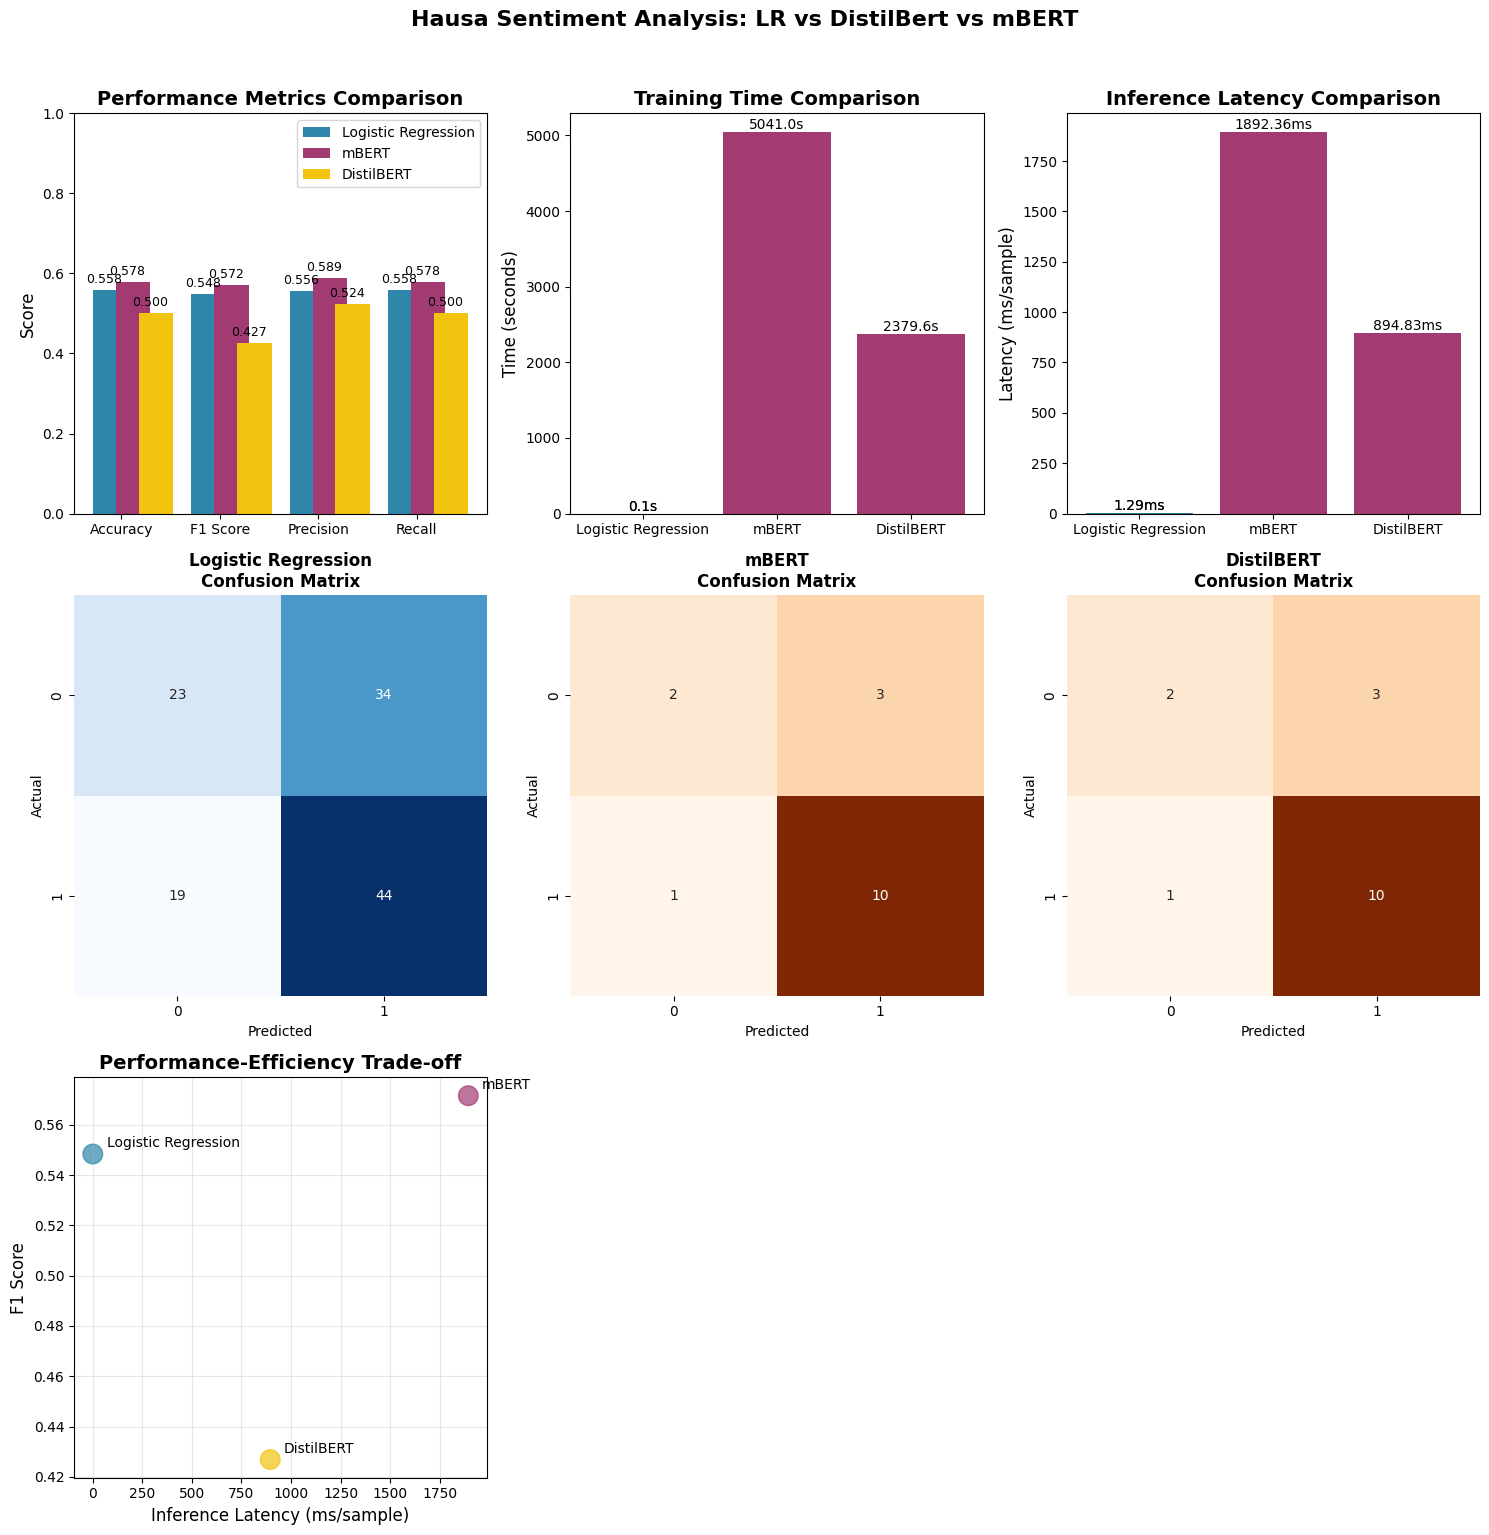

In [42]:
# Plot comparison

#import matplotlib and seaborn for plotting
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix 

lr_scores = df_comparison[df_comparison['model'] == 'LogisticRegression'].loc[0, ['eval_accuracy', 'eval_f1', 'eval_precision', 'eval_recall','training time (s)','inference latency (ms)']]
bert_scores = df_comparison[df_comparison['model'] == 'bert-base-multilingual-cased'].loc[2, ['eval_accuracy', 'eval_f1', 'eval_precision', 'eval_recall','training time (s)','inference latency (ms)']]
d_bert_scores = df_comparison[df_comparison['model'] == 'distilbert-base-multilingual-cased'].loc[1, ['eval_accuracy', 'eval_f1', 'eval_precision', 'eval_recall','training time (s)','inference latency (ms)']]

# Create comprehensive visualization
fig = plt.figure(figsize=(15, 15))

# 1. Performance metrics comparison
ax1 = plt.subplot(3, 3, 1)
metrics = ['Accuracy', 'F1 Score', 'Precision', 'Recall']
x = np.arange(len(metrics))
width = 0.35
lr_eval = lr_scores[['eval_accuracy', 'eval_f1', 'eval_precision', 'eval_recall']]
bert_eval = bert_scores[['eval_accuracy', 'eval_f1', 'eval_precision', 'eval_recall']]
d_bert_eval = d_bert_scores[['eval_accuracy', 'eval_f1', 'eval_precision', 'eval_recall']]
print(lr_eval,'\n',bert_eval,'\n',d_bert_eval)

bars1 = ax1.bar(x - width/3, lr_eval, width, label='Logistic Regression', color='#2E86AB')
bars2 = ax1.bar(x + width/3, bert_eval, width, label='mBERT', color='#A23B72')
bars3 = ax1.bar(x + 3*width/3, d_bert_eval, width, label='DistilBERT', color='#F1C40F')
ax1.set_ylabel('Score', fontsize=12)
ax1.set_title('Performance Metrics Comparison', fontsize=14, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(metrics)
ax1.legend()
ax1.set_ylim([0, 1])
# Add value labels
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/3., height + 0.01,
                f'{height:.3f}', ha='center', va='bottom', fontsize=9)

# 2. Training time comparison
ax2 = plt.subplot(3, 3, 2)
times1 = [lr_scores['training time (s)'], bert_scores['training time (s)']]
times2 = [lr_scores['training time (s)'], d_bert_scores['training time (s)']]
bars4 = ax2.bar(['Logistic Regression', 'mBERT'], times1, color=['#2E86AB', '#A23B72'])
bars5 = ax2.bar(['Logistic Regression', 'DistilBERT'], times2, color=['#2E86AB', '#A23B72'])
ax2.set_ylabel('Time (seconds)', fontsize=12)
ax2.set_title('Training Time Comparison', fontsize=14, fontweight='bold')
# Add value labels
for bars in [bars4, bars5]:
    for bar in bars:
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2., height + 0.5,
                f'{height:.1f}s', ha='center', va='bottom', fontsize=10)

# 3. Inference latency comparison
ax3 = plt.subplot(3, 3, 3)
latencies1 = [lr_scores['inference latency (ms)'], bert_scores['inference latency (ms)']]
latencies2 = [lr_scores['inference latency (ms)'], d_bert_scores['inference latency (ms)']]
bars6 = ax3.bar(['Logistic Regression', 'mBERT'], latencies1, color=['#2E86AB', '#A23B72'])
bars7 = ax3.bar(['Logistic Regression', 'DistilBERT'], latencies2, color=['#2E86AB', '#A23B72'])
ax3.set_ylabel('Latency (ms/sample)', fontsize=12)
ax3.set_title('Inference Latency Comparison', fontsize=14, fontweight='bold')
# Add value labels
for bars in [bars6, bars7]:
    for bar in bars:
        height = bar.get_height()
        ax3.text(bar.get_x() + bar.get_width()/2., height + 1,
                f'{height:.2f}ms', ha='center', va='bottom', fontsize=10)

# 4. Confusion Matrix - Logistic Regression
ax4 = plt.subplot(3, 3, 4)
cm_lr = confusion_matrix(y_test, y_pred_lr)
sns.heatmap(cm_lr, annot=True, fmt='d', ax=ax4, cmap='Blues', cbar=False)
ax4.set_xlabel('Predicted', fontsize=10)
ax4.set_ylabel('Actual', fontsize=10)
ax4.set_title('Logistic Regression\nConfusion Matrix', fontsize=12, fontweight='bold')

# 5. Confusion Matrix - mBERT
ax5 = plt.subplot(3, 3, 5)
# Get mBERT predictions

cm_bert = confusion_matrix(eval_data['bert-base-multilingual-cased']['label'], models_cm['bert-base-multilingual-cased'])  # Use stored predictions for confusion matrix
sns.heatmap(cm_bert, annot=True, fmt='d', ax=ax5, cmap='Oranges', cbar=False)
ax5.set_xlabel('Predicted', fontsize=10)
ax5.set_ylabel('Actual', fontsize=10)
ax5.set_title('mBERT\nConfusion Matrix', fontsize=12, fontweight='bold')

# 6. Confusion Matrix - DistilBERT
ax6 = plt.subplot(3, 3, 6)
# Get DistilBERT predictions
cm_distilbert = confusion_matrix(eval_data['distilbert-base-multilingual-cased']['label'], models_cm['distilbert-base-multilingual-cased'])
sns.heatmap(cm_distilbert, annot=True, fmt='d', ax=ax6, cmap='Oranges', cbar=False)
ax6.set_xlabel('Predicted', fontsize=10)
ax6.set_ylabel('Actual', fontsize=10)
ax6.set_title('DistilBERT\nConfusion Matrix', fontsize=12, fontweight='bold')

# 7. Efficiency vs Performance trade-off
ax7 = plt.subplot(3, 3, 7)
# Create scatter plot of F1 vs Inference Latency
models = ['Logistic Regression', 'mBERT','DistilBERT']
f1_scores = [lr_scores['eval_f1'], bert_scores['eval_f1'], d_bert_scores['eval_f1']]
latencies_plot = [lr_scores['inference latency (ms)'], bert_scores['inference latency (ms)'], d_bert_scores['inference latency (ms)']]
scatter = ax7.scatter(latencies_plot, f1_scores, s=200, c=['#2E86AB', '#A23B72', '#F1C40F'], alpha=0.7)
for i, model in enumerate(models):
    ax7.annotate(model, (latencies_plot[i], f1_scores[i]), 
                xytext=(10, 5), textcoords='offset points', fontsize=10)
ax7.set_xlabel('Inference Latency (ms/sample)', fontsize=12)
ax7.set_ylabel('F1 Score', fontsize=12)
ax7.set_title('Performance-Efficiency Trade-off', fontsize=14, fontweight='bold')
ax7.grid(True, alpha=0.3)

plt.suptitle('Hausa Sentiment Analysis: LR vs DistilBert vs mBERT', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(PATH / 'hausa_sentiment_comparison.png', dpi=300, bbox_inches='tight')

plt.show()

#### 6. ADDITIONAL ANALYSIS WITH HUGGING FACE DATASETS

In [43]:

if data_source == 'HF':
    print("\n" + "="*60)
    print("ADDITIONAL DATASET ANALYSIS")
    print("="*60)

    # Analyze dataset using Hugging Face capabilities
    print("\nDataset Statistics using Hugging Face:")
    print(f"  Dataset features: {train_dataset.features}")
    print(f"  Number of unique labels: {len(np.unique(train_dataset['label']))}")

    # Text length analysis
    train_lengths = [len(text.split()) for text in train_dataset['text']]
    test_lengths = [len(text.split()) for text in final_test_dataset['text']]

    print(f"\nText Length Statistics:")
    print(f"\nTraining - Mean: {np.mean(train_lengths):.1f} words, Max: {np.max(train_lengths)} words")
    print(f"\nTest - Mean: {np.mean(test_lengths):.1f} words, Max: {np.max(test_lengths)} words")

#### 7. CONCLUSION

In [44]:

print("\n" + "="*60)
print("CONCLUSION")
print("="*60)

speedup_factor_bert = bert_scores.loc['training time (s)'] / lr_scores.loc['training time (s)'] if lr_scores.loc['training time (s)'] > 0 else 0
latency_ratio_bert = bert_scores.loc['inference latency (ms)'] / lr_scores.loc['inference latency (ms)'] if lr_scores.loc['inference latency (ms)'] > 0 else 0

speedup_factor_distilbert = d_bert_scores.loc['training time (s)'] / lr_scores.loc['training time (s)'] if lr_scores.loc['training time (s)'] > 0 else 0
latency_ratio_distilbert = d_bert_scores.loc['inference latency (ms)'] / lr_scores.loc['inference latency (ms)'] if lr_scores.loc['inference latency (ms)'] > 0 else 0

print(f"\nKey Findings:")
print(f"  • Logistic Regression trains {speedup_factor_bert:.1f}x faster than mBERT")
print(f"  • mBERT has {latency_ratio_bert:.1f}x higher inference latency")
print(f"  • Performance difference: {abs(lr_scores.loc['eval_accuracy'] - bert_scores.loc['eval_accuracy'])*100:.1f}% in accuracy")
print(f"  • mBERT provides better generalization for complex patterns")

print(f"\nKey Findings:")
print(f"  • Logistic Regression trains {speedup_factor_distilbert:.1f}x faster than DistilBERT")
print(f"  • DistilBERT has {latency_ratio_distilbert:.1f}x higher inference latency")
print(f"  • Performance difference: {abs(lr_scores.loc['eval_accuracy'] - d_bert_scores.loc['eval_accuracy'])*100:.1f}% in accuracy")
print(f"  • DistilBERT provides a good balance between performance and efficiency")

print(f"\nRecommendations:")
if bert_scores.loc['eval_accuracy'] > lr_scores.loc['eval_accuracy'] + 0.05:
    print("Use mBERT if accuracy is critical and resources are available")
    print("Logistic Regression works well as a fast baseline")
elif d_bert_scores.loc['eval_accuracy'] > lr_scores.loc['eval_accuracy'] + 0.05:
    print("Use DistilBERT if accuracy is critical and resources are limited")
    print("Logistic Regression works well as a fast baseline")
else:
    print("Logistic Regression offers excellent performance with minimal resources")
    print("mBERT might be overkill for this dataset size")

print(f"\nHugging Face Integration Benefits:")
print("  • Seamless dataset preprocessing and tokenization")
print("  • Built-in train/test splitting with stratification")
print("  • Easy integration with Transformers library")
print("  • Efficient memory management for large datasets")

print("\nProject complete.")
print("\nComparison results saved as 'model_comparison_results.csv'")
print("\nComparison plot saved as 'hausa_sentiment_comparison.png'")

# Optional: Save results and datasets
df_comparison.to_csv(PATH / 'model_comparison_results.csv', index=False)
print("Results saved to 'model_comparison_results.csv'")

# Save processed datasets for future use
train_dataset.save_to_disk(PATH / 'hausa_train_dataset.csv')
final_test_dataset.save_to_disk(PATH / 'hausa_test_dataset.csv')
print("Processed datasets saved to 'hausa_train_dataset' and 'hausa_test_dataset' directories")


CONCLUSION

Key Findings:
  • Logistic Regression trains 70365.8x faster than mBERT
  • mBERT has 1470.7x higher inference latency
  • Performance difference: 2.0% in accuracy
  • mBERT provides better generalization for complex patterns

Key Findings:
  • Logistic Regression trains 33216.5x faster than DistilBERT
  • DistilBERT has 695.5x higher inference latency
  • Performance difference: 5.8% in accuracy
  • DistilBERT provides a good balance between performance and efficiency

Recommendations:
Logistic Regression offers excellent performance with minimal resources
mBERT might be overkill for this dataset size

Hugging Face Integration Benefits:
  • Seamless dataset preprocessing and tokenization
  • Built-in train/test splitting with stratification
  • Easy integration with Transformers library
  • Efficient memory management for large datasets

Project complete.

Comparison results saved as 'model_comparison_results.csv'

Comparison plot saved as 'hausa_sentiment_comparison.png'

Saving the dataset (1/1 shards): 100%|██████████| 64/64 [00:00<00:00, 539.15 examples/s]


Processed datasets saved to 'hausa_train_dataset' and 'hausa_test_dataset' directories
